# EVAT EV Suitability Prediction and Recommendation Use Case

This notebook was created as part of the EVAT Data Science contribution for the Personalised EV Usage Insights use case.

The purpose of this notebook is to build a practical prediction and recommendation layer using the EVAT user response dataset that is already connected through the backend, MongoDB, and Power BI workflow.

# Project Overview

This notebook was developed for the EVAT EV Suitability Prediction and Recommendation use case.

The main aim of this work is to analyse user driving behaviour and generate:
- EV suitability prediction
- EV readiness score
- recommendation category
- estimated fuel savings
- personalised prediction insights

The final output is prepared in a format that can be connected with Power BI dashboards and future EVAT system integrations.


## EVAT Data Flow Context

The dataset used in this notebook comes from the EVAT user response workflow.

Current project flow:

User Responses → Backend Integration → MongoDB → Power BI Dashboard → Data Science Prediction and Recommendation Layer

The Power BI dashboard already visualises user response data. This notebook adds a predictive and recommendation layer on top of that data so the dashboard can move from simple reporting to intelligent user insights.


## Import Required Libraries

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier

import warnings
warnings.filterwarnings("ignore")


## Loading the Dataset

The EVAT dataset is loaded into a dataframe for analysis.

The dataset contains user driving and fuel usage information that is used for the EV suitability prediction process.

In [18]:
df = pd.read_csv("EVAT.user_responses.csv")

print("Dataset shape:", df.shape)
df.head()


Dataset shape: (1006, 18)


,_id,timestamp,weekly_km,trip_length,driving_frequency,driving_type,road_trips,car_ownership,fuel_efficiency,monthly_fuel_spend,home_charging,solar_panels,charging_preference,budget,priorities,postcode,cluster,email
0,68a47f443b0a7c90ff10ff53,28/08/2025 19:06,94,Mostly medium trips (10-50 km),A few times a week,A mix of city/suburban and highway driving,No,Yes - Petrol,8.7,50.96,No,Yes,Home,">$80,000","Cost savings, Tech features",3862,3.0,NaN
1,68a47f443b0a7c90ff10ff62,25/07/2025 2:45,87,Mostly medium trips (10-50 km),A few times a week,A mix of city/suburban and highway driving,No,Yes - Petrol,9.1,69.05,Yes,Yes,Work,"$60,000 -$80,000","Cost savings, Brand reputation",3185,3.0,NaN
2,68a47f443b0a7c90ff10ffd7,29/08/2025 9:44,39,Mostly short trips (<10 km),A few times a week,Mostly inner-city or suburban driving (short d...,No,Yes - Petrol,8.9,26.45,No,No,Home,">$80,000","Cost savings, Performance",3918,3.0,NaN
3,68a47f443b0a7c90ff110064,9/08/2025 17:09,68,Mostly short trips (<10 km),Daily,Mostly inner-city or suburban driving (short d...,No,Yes - Diesel,5.4,30.24,No,Yes,Work,"$60,000 -$80,000","Environmental impact, Performance",3065,3.0,NaN
4,68a47f443b0a7c90ff110070,15/08/2025 5:24,208,Mostly medium trips (10-50 km),Daily,A mix of city/suburban and highway driving,No,Yes - Electric,0.0,36.92,No,No,Home,"<$40,000","Charging convenience, Environmental impact",3395,1.0,NaN


## Initial Data Exploration

Basic exploration is performed to understand:
- dataset structure
- available features
- missing values
- data types

This step helps identify the important columns required for the prediction use case.

In [19]:
print("Columns in dataset:")
print(df.columns)

print("\nMissing values:")
print(df.isnull().sum())


Columns in dataset:
Index(['_id', 'timestamp', 'weekly_km', 'trip_length', 'driving_frequency',
       'driving_type', 'road_trips', 'car_ownership', 'fuel_efficiency',
       'monthly_fuel_spend', 'home_charging', 'solar_panels',
       'charging_preference', 'budget', 'priorities', 'postcode', 'cluster',
       'email'],
      dtype='object')

Missing values:
_id                       0
timestamp                 5
weekly_km                 0
trip_length               0
driving_frequency         0
driving_type              0
road_trips                0
car_ownership             0
fuel_efficiency           0
monthly_fuel_spend        0
home_charging             0
solar_panels              0
charging_preference       0
budget                    0
priorities                0
postcode                  0
cluster                   4
email                  1001
dtype: int64


## Initial Data Exploration

Basic exploration is performed to understand:
- dataset structure
- available features
- missing values
- data types

This step helps identify the important columns required for the prediction use case.


In [20]:
# Keep identifier fields separately for Power BI/MongoDB relational integration

identifier_cols = ["_id", "email", "timestamp", "cluster"]

available_identifier_cols = [
    col for col in identifier_cols
    if col in df.columns
]

df_identifiers = df[available_identifier_cols].copy()

# Rename _id to id for easier Power BI relationship usage
if "_id" in df_identifiers.columns:
    df_identifiers = df_identifiers.rename(columns={"_id": "id"})

print("Identifier columns retained for export:")
print(df_identifiers.columns.tolist())

# Create modelling dataframe
df_clean = df.copy()

# Drop only fields that should not be used as modelling features
# cluster is kept in df_model for final export, but later removed from ML features
columns_to_drop_for_modelling_base = ["_id", "email", "timestamp", "postcode"]

for col in columns_to_drop_for_modelling_base:
    if col in df_clean.columns:
        df_clean.drop(columns=col, inplace=True)

df_clean.head()


Identifier columns retained for export:
['id', 'email', 'timestamp', 'cluster']


,weekly_km,trip_length,driving_frequency,driving_type,road_trips,car_ownership,fuel_efficiency,monthly_fuel_spend,home_charging,solar_panels,charging_preference,budget,priorities,cluster
0,94,Mostly medium trips (10-50 km),A few times a week,A mix of city/suburban and highway driving,No,Yes - Petrol,8.7,50.96,No,Yes,Home,">$80,000","Cost savings, Tech features",3.0
1,87,Mostly medium trips (10-50 km),A few times a week,A mix of city/suburban and highway driving,No,Yes - Petrol,9.1,69.05,Yes,Yes,Work,"$60,000 -$80,000","Cost savings, Brand reputation",3.0
2,39,Mostly short trips (<10 km),A few times a week,Mostly inner-city or suburban driving (short d...,No,Yes - Petrol,8.9,26.45,No,No,Home,">$80,000","Cost savings, Performance",3.0
3,68,Mostly short trips (<10 km),Daily,Mostly inner-city or suburban driving (short d...,No,Yes - Diesel,5.4,30.24,No,Yes,Work,"$60,000 -$80,000","Environmental impact, Performance",3.0
4,208,Mostly medium trips (10-50 km),Daily,A mix of city/suburban and highway driving,No,Yes - Electric,0.0,36.92,No,No,Home,"<$40,000","Charging convenience, Environmental impact",1.0


## Feature Selection

Important driving and fuel usage features are selected for the EV suitability prediction process.

These features are used to calculate readiness scores and generate recommendation outputs.

In [21]:
# Adjustable assumptions for the current prototype
fuel_price_per_litre = 2.00
ev_efficiency_kwh_per_100km = 16
electricity_price_per_kwh = 0.30
co2_kg_per_litre_petrol = 2.31

df_model = df_clean.copy()

df_model["annual_km"] = df_model["weekly_km"] * 52

df_model["annual_fuel_cost"] = df_model["monthly_fuel_spend"] * 12

df_model["estimated_ev_kwh_per_year"] = (
    df_model["annual_km"] / 100
) * ev_efficiency_kwh_per_100km

df_model["estimated_ev_charging_cost"] = (
    df_model["estimated_ev_kwh_per_year"] * electricity_price_per_kwh
)

df_model["estimated_annual_savings"] = (
    df_model["annual_fuel_cost"] - df_model["estimated_ev_charging_cost"]
)

df_model["estimated_annual_savings"] = df_model[
    "estimated_annual_savings"
].clip(lower=0)

df_model["estimated_litres_per_year"] = (
    df_model["annual_km"] * df_model["fuel_efficiency"] / 100
)

df_model["estimated_co2_reduction_kg"] = (
    df_model["estimated_litres_per_year"] * co2_kg_per_litre_petrol
)

df_model[[
    "weekly_km",
    "annual_km",
    "monthly_fuel_spend",
    "annual_fuel_cost",
    "estimated_ev_charging_cost",
    "estimated_annual_savings",
    "estimated_co2_reduction_kg"
]].head()


,weekly_km,annual_km,monthly_fuel_spend,annual_fuel_cost,estimated_ev_charging_cost,estimated_annual_savings,estimated_co2_reduction_kg
0,94,4888,50.96,611.52,234.624,376.896,982.34136
1,87,4524,69.05,828.60,217.152,611.448,950.99004
2,39,2028,26.45,317.40,97.344,220.056,416.93652
3,68,3536,30.24,362.88,169.728,193.152,441.08064
4,208,10816,36.92,443.04,519.168,0.000,0.00000


## EV Readiness Scoring

An EV readiness score is calculated using user driving behaviour and fuel usage information.

The purpose of this score is to estimate how suitable a user may be for EV adoption based on their usage patterns.


In [22]:
def calculate_ev_suitability_score(row):
    score = 0

    # Driving demand
    annual_km = row["annual_km"]
    score += min(annual_km / 1000, 25)

    # Fuel savings potential
    annual_savings = row["estimated_annual_savings"]
    score += min(annual_savings / 80, 25)

    # CO2 reduction potential
    co2_reduction = row["estimated_co2_reduction_kg"]
    score += min(co2_reduction / 120, 20)

    # Charging practicality
    if str(row["home_charging"]).lower() == "yes":
        score += 18
    elif str(row["charging_preference"]).lower() in ["work", "public"]:
        score += 10

    # Solar panel support
    if str(row["solar_panels"]).lower() == "yes":
        score += 8

    # Environmental priority
    priorities = str(row.get("priorities", "")).lower()
    if "environment" in priorities:
        score += 5

    # Budget constraint
    budget = str(row.get("budget", "")).lower()
    if "<$40,000" in budget or "low" in budget:
        score -= 5

    return max(min(score, 100), 0)

df_model["ev_suitability_score"] = df_model.apply(
    calculate_ev_suitability_score,
    axis=1
)

df_model[[
    "annual_km",
    "estimated_annual_savings",
    "estimated_co2_reduction_kg",
    "home_charging",
    "solar_panels",
    "ev_suitability_score"
]].head()


,annual_km,estimated_annual_savings,estimated_co2_reduction_kg,home_charging,solar_panels,ev_suitability_score
0,4888,376.896,982.34136,No,Yes,25.785378
1,4524,611.448,950.99004,Yes,Yes,46.092017
2,2028,220.056,416.93652,No,No,8.253171
3,3536,193.152,441.08064,No,Yes,32.626072
4,10816,0.000,0.00000,No,No,10.816000


## Recommendation Logic

Recommendation categories are generated based on EV readiness score values and driving behaviour.

Example recommendation outputs include:
- Full EV Recommended
- Hybrid Recommended
- EV Optional

This recommendation logic can be improved further in future EVAT development stages using additional behavioural and real-world EV adoption data.


In [23]:
def assign_ev_recommendation(score):
    if score >= 70:
        return "Full EV Recommended"
    elif score >= 45:
        return "Hybrid Recommended"
    else:
        return "EV Optional"

df_model["ev_recommendation_prediction"] = df_model[
    "ev_suitability_score"
].apply(assign_ev_recommendation)

df_model[[
    "ev_suitability_score",
    "ev_recommendation_prediction"
]].head()


,ev_suitability_score,ev_recommendation_prediction
0,25.785378,EV Optional
1,46.092017,Hybrid Recommended
2,8.253171,EV Optional
3,32.626072,EV Optional
4,10.816000,EV Optional


## Personalised Prediction Insights

A personalised prediction insight is generated for each user based on the recommendation output.

These insights are designed to make the prediction results easier to understand within dashboards and future frontend integrations.


In [24]:
def generate_recommendation_insight(row):
    if row["ev_recommendation_prediction"] == "Full EV Recommended":
        return (
            f"Strong EV suitability based on driving demand, estimated yearly savings of "
            f"${row['estimated_annual_savings']:.0f}, and potential CO2 reduction of "
            f"{row['estimated_co2_reduction_kg']:.0f} kg per year."
        )

    elif row["ev_recommendation_prediction"] == "Hybrid Recommended":
        return (
            f"Moderate EV suitability. A hybrid or gradual EV transition may be suitable, "
            f"with estimated yearly savings of ${row['estimated_annual_savings']:.0f}."
        )

    else:
        return (
            "EV adoption is optional at this stage because estimated savings, driving demand, "
            "or charging practicality may currently be limited."
        )

df_model["personalised_prediction_insight"] = df_model.apply(
    generate_recommendation_insight,
    axis=1
)

df_model[[
    "ev_recommendation_prediction",
    "personalised_prediction_insight"
]].head()


,ev_recommendation_prediction,personalised_prediction_insight
0,EV Optional,EV adoption is optional at this stage because ...
1,Hybrid Recommended,Moderate EV suitability. A hybrid or gradual E...
2,EV Optional,EV adoption is optional at this stage because ...
3,EV Optional,EV adoption is optional at this stage because ...
4,EV Optional,EV adoption is optional at this stage because ...


## Recommendation Distribution

This chart shows how users are distributed across the recommendation categories.

This is useful for checking whether the output is suitable for a Power BI recommendation distribution chart.


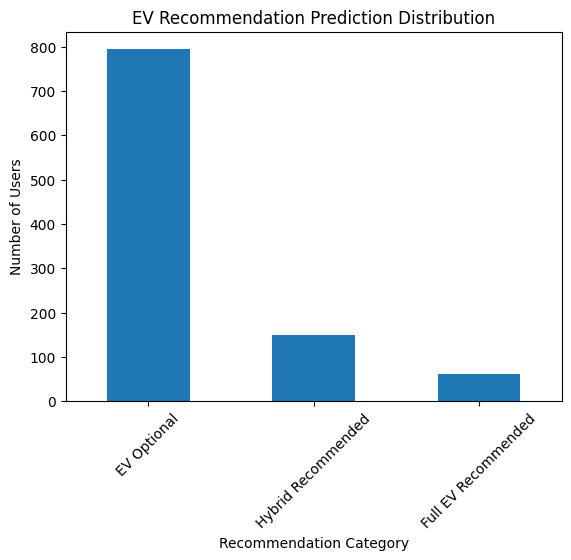

In [25]:
df_model["ev_recommendation_prediction"].value_counts().plot(kind="bar")

plt.title("EV Recommendation Prediction Distribution")
plt.xlabel("Recommendation Category")
plt.ylabel("Number of Users")
plt.xticks(rotation=45)

plt.show()


## Average Estimated Savings by Recommendation

This chart checks whether stronger recommendations align with higher estimated fuel savings.

This supports the usefulness of the prediction output in the dashboard.


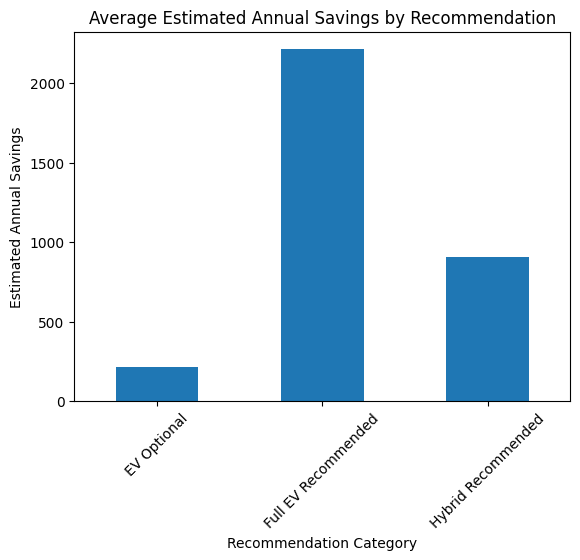

In [26]:
df_model.groupby(
    "ev_recommendation_prediction"
)["estimated_annual_savings"].mean().plot(kind="bar")

plt.title("Average Estimated Annual Savings by Recommendation")
plt.xlabel("Recommendation Category")
plt.ylabel("Estimated Annual Savings")
plt.xticks(rotation=45)

plt.show()


## Machine Learning Prediction Setup

The machine learning models are trained to predict the recommendation category using user behaviour and engineered suitability features.

Important note:

The recommendation target is generated from the current EV suitability framework because real-world EV adoption labels are not yet available. Therefore, this ML component is a first-stage prediction model that learns and automates the recommendation framework.

Identifier fields such as `id`, `email`, and `timestamp` are not used for model training. They are retained only for the final exported CSV so the output can be connected properly in Power BI with the MongoDB/API dataset.

This is useful now because it allows the team to compare models, understand feature importance, and prepare the logic for future API or Power BI integration.


In [27]:
ml_df = df_model.copy()

target = "ev_recommendation_prediction"

drop_cols = [
    target,
    "personalised_prediction_insight",
    "ev_suitability_score",
    "cluster"
]

drop_cols = [col for col in drop_cols if col in ml_df.columns]

X = ml_df.drop(columns=drop_cols)
y = ml_df[target]

label_encoders = {}

for col in X.columns:
    if X[col].dtype == "object":
        le = LabelEncoder()
        X[col] = X[col].astype(str)
        X[col] = le.fit_transform(X[col])
        label_encoders[col] = le

target_encoder = LabelEncoder()
y_encoded = target_encoder.fit_transform(y)

print("Features used for prediction:")
print(X.columns.tolist())

print("\nTarget classes:")
print(list(target_encoder.classes_))

print("\nFeature shape:", X.shape)
print("Target shape:", y_encoded.shape)


Features used for prediction:
['weekly_km', 'trip_length', 'driving_frequency', 'driving_type', 'road_trips', 'car_ownership', 'fuel_efficiency', 'monthly_fuel_spend', 'home_charging', 'solar_panels', 'charging_preference', 'budget', 'priorities', 'annual_km', 'annual_fuel_cost', 'estimated_ev_kwh_per_year', 'estimated_ev_charging_cost', 'estimated_annual_savings', 'estimated_litres_per_year', 'estimated_co2_reduction_kg']

Target classes:
['EV Optional', 'Full EV Recommended', 'Hybrid Recommended']

Feature shape: (1006, 20)
Target shape: (1006,)


## Train and Compare Prediction Models

Four models are trained and compared:

- Logistic Regression
- Random Forest
- Gradient Boosting
- Extra Trees

Weighted F1-score is used because recommendation categories may not be evenly distributed.


In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    ),

    "Extra Trees": ExtraTreesClassifier(
        n_estimators=200,
        random_state=42
    )
}

results = []
trained_models = {}

for name, model in models.items():

    pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="mean")),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)
    predictions = pipeline.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": round(accuracy_score(y_test, predictions), 4),
        "Precision": round(precision_score(y_test, predictions, average="weighted", zero_division=0), 4),
        "Recall": round(recall_score(y_test, predictions, average="weighted", zero_division=0), 4),
        "F1-score": round(f1_score(y_test, predictions, average="weighted", zero_division=0), 4)
    })

    trained_models[name] = pipeline

results_df = pd.DataFrame(results).sort_values(
    by="F1-score",
    ascending=False
)

results_df


,Model,Accuracy,Precision,Recall,F1-score
3,Extra Trees,0.9604,0.9607,0.9604,0.9604
1,Random Forest,0.9455,0.9481,0.9455,0.9464
2,Gradient Boosting,0.9455,0.9465,0.9455,0.9458
0,Logistic Regression,0.9257,0.9315,0.9257,0.9275


## Best Prediction Model

The best model is selected using weighted F1-score.

The classification report and confusion matrix are used to check how the model performs across each recommendation category.


In [29]:
best_model_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]

print("Best Model:", best_model_name)
print("Best F1-score:", results_df.iloc[0]["F1-score"])
print("Best Accuracy:", results_df.iloc[0]["Accuracy"])

best_predictions = best_model.predict(X_test)

print("\nClassification Report:")
print(classification_report(
    y_test,
    best_predictions,
    target_names=target_encoder.classes_
))

print("Confusion Matrix:")
print(confusion_matrix(y_test, best_predictions))


Best Model: Extra Trees
Best F1-score: 0.9604
Best Accuracy: 0.9604

Classification Report:
                     precision    recall  f1-score   support

        EV Optional       0.98      0.97      0.98       159
Full EV Recommended       0.93      1.00      0.96        13
 Hybrid Recommended       0.87      0.87      0.87        30

           accuracy                           0.96       202
          macro avg       0.93      0.95      0.94       202
       weighted avg       0.96      0.96      0.96       202

Confusion Matrix:
[[155   0   4]
 [  0  13   0]
 [  3   1  26]]


## Cross-Validation

Cross-validation is used to check whether the selected model performs consistently across different data splits.

This gives a more reliable view of model stability than one train-test split alone.


In [30]:
cv_scores = cross_val_score(
    best_model,
    X,
    y_encoded,
    cv=5,
    scoring="f1_weighted"
)

print("Cross-validation F1 scores:")
print(cv_scores)

print("\nMean CV F1-score:", round(cv_scores.mean(), 4))
print("Standard deviation:", round(cv_scores.std(), 4))


Cross-validation F1 scores:
[0.94554145 0.94464118 0.94922925 0.94949206 0.96491823]

Mean CV F1-score: 0.9508
Standard deviation: 0.0073


## EV Readiness Score Distribution

The EV readiness score distribution is visualised to understand how suitability scores vary across users in the dataset.


Top 10 Important Features:
                       Feature  Importance
19  estimated_co2_reduction_kg    0.109014
0                    weekly_km    0.100518
18   estimated_litres_per_year    0.099814
16  estimated_ev_charging_cost    0.096617
13                   annual_km    0.091856
7           monthly_fuel_spend    0.085457
14            annual_fuel_cost    0.081148
15   estimated_ev_kwh_per_year    0.075550
8                home_charging    0.053593
17    estimated_annual_savings    0.052130


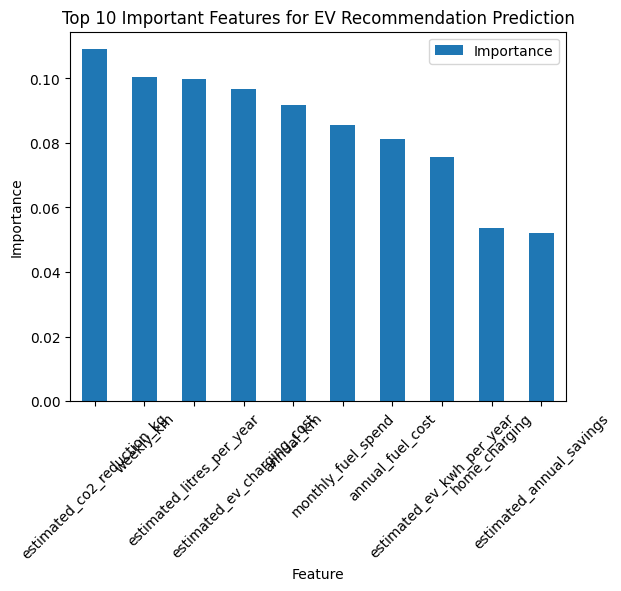

In [31]:
final_model = best_model.named_steps["model"]

if hasattr(final_model, "feature_importances_"):

    importance_df = pd.DataFrame({
        "Feature": X.columns,
        "Importance": final_model.feature_importances_
    }).sort_values(by="Importance", ascending=False)

    print("Top 10 Important Features:")
    print(importance_df.head(10))

    importance_df.head(10).plot(
        x="Feature",
        y="Importance",
        kind="bar"
    )

    plt.title("Top 10 Important Features for EV Recommendation Prediction")
    plt.xlabel("Feature")
    plt.ylabel("Importance")
    plt.xticks(rotation=45)

    plt.show()

else:
    print("Feature importance is not available for this model.")


## Why This Notebook Is Useful Now

This notebook is useful for the current EVAT project because it produces Power BI-ready outputs:

- EV suitability score
- EV recommendation prediction
- estimated annual savings
- estimated CO₂ reduction
- personalised prediction insight
- feature importance ranking

These outputs can be tested in Power BI using:

- score cards
- recommendation slicers
- recommendation distribution charts
- user-level insight tables
- savings and emissions visuals

This means the notebook can immediately support dashboard enhancement even before full backend/API deployment.


## How the Next Data Science Member Can Use This Notebook

The next EVAT Data Science member can use this notebook as a starting point for continuing the prediction use case.

Recommended next steps:

1. Validate the recommendation logic with project mentors or domain experts.
2. Replace rule-generated labels with expert-labelled recommendations if available.
3. Add real EV adoption outcome data if collected later.
4. Add postcode-based charging infrastructure features.
5. Add fuel savings and payback period calculations.
6. Convert the final logic into a backend API function.
7. Store recommendation outputs back into MongoDB.
8. Connect the output dynamically to Power BI.

This notebook therefore works as both a current prototype and a handover base for future development.


## Limitation and Correct Interpretation

The current prediction target is generated from the EV suitability framework created in this notebook. This means the model is learning to reproduce the recommendation framework, not predicting verified real-world EV adoption outcomes.

This is acceptable for a first-stage capstone prototype because the purpose is to create an explainable recommendation layer and prepare the workflow for dashboard/API integration.

The model should be described as:

**A first-stage EV suitability prediction and recommendation model based on engineered behavioural, financial, and charging-related indicators.**

It should not yet be described as:

**A fully validated real-world EV adoption prediction model.**

Future validation should use expert-labelled or real adoption outcome data.


## Export Power BI-Ready Output with Identifier Fields

The final output file is designed for Power BI integration.

To avoid disconnected tables in Power BI, the exported CSV retains common fields from the original dataset where available:

- id
- email
- timestamp
- cluster

The final CSV also includes:

- weekly_km
- monthly_fuel_spend
- estimated_annual_savings
- estimated_co2_reduction_kg
- ev_suitability_score
- ev_recommendation_prediction
- personalised_prediction_insight

This allows the recommendation output to be related back to the MongoDB/API/Power BI dataset using a common identifier such as `id`, `email`, or `timestamp`.


In [32]:
# Build Power BI-ready export with identifier fields

export_df = pd.concat(
    [
        df_identifiers.reset_index(drop=True),
        df_model.reset_index(drop=True)
    ],
    axis=1
)

# Remove duplicate columns if any exist after concat
export_df = export_df.loc[:, ~export_df.columns.duplicated()]

# Select preferred output columns if available
preferred_export_cols = [
    "id",
    "email",
    "timestamp",
    "weekly_km",
    "monthly_fuel_spend",
    "cluster",
    "annual_km",
    "estimated_annual_savings",
    "estimated_co2_reduction_kg",
    "ev_suitability_score",
    "ev_recommendation_prediction",
    "personalised_prediction_insight"
]

available_export_cols = [
    col for col in preferred_export_cols
    if col in export_df.columns
]

remaining_cols = [
    col for col in export_df.columns
    if col not in available_export_cols
]

export_df = export_df[available_export_cols + remaining_cols]

export_df.to_csv(
    "EVAT_prediction_recommendation_output_powerbi_linked.csv",
    index=False
)

print("Saved as EVAT_prediction_recommendation_output_powerbi_linked.csv")

print("\nColumns exported:")
print(export_df.columns.tolist())

export_df[available_export_cols].head()


Saved as EVAT_prediction_recommendation_output_powerbi_linked.csv

Columns exported:
['id', 'email', 'timestamp', 'weekly_km', 'monthly_fuel_spend', 'cluster', 'annual_km', 'estimated_annual_savings', 'estimated_co2_reduction_kg', 'ev_suitability_score', 'ev_recommendation_prediction', 'personalised_prediction_insight', 'trip_length', 'driving_frequency', 'driving_type', 'road_trips', 'car_ownership', 'fuel_efficiency', 'home_charging', 'solar_panels', 'charging_preference', 'budget', 'priorities', 'annual_fuel_cost', 'estimated_ev_kwh_per_year', 'estimated_ev_charging_cost', 'estimated_litres_per_year']


,id,email,timestamp,weekly_km,monthly_fuel_spend,cluster,annual_km,estimated_annual_savings,estimated_co2_reduction_kg,ev_suitability_score,ev_recommendation_prediction,personalised_prediction_insight
0,68a47f443b0a7c90ff10ff53,NaN,28/08/2025 19:06,94,50.96,3.0,4888,376.896,982.34136,25.785378,EV Optional,EV adoption is optional at this stage because ...
1,68a47f443b0a7c90ff10ff62,NaN,25/07/2025 2:45,87,69.05,3.0,4524,611.448,950.99004,46.092017,Hybrid Recommended,Moderate EV suitability. A hybrid or gradual E...
2,68a47f443b0a7c90ff10ffd7,NaN,29/08/2025 9:44,39,26.45,3.0,2028,220.056,416.93652,8.253171,EV Optional,EV adoption is optional at this stage because ...
3,68a47f443b0a7c90ff110064,NaN,9/08/2025 17:09,68,30.24,3.0,3536,193.152,441.08064,32.626072,EV Optional,EV adoption is optional at this stage because ...
4,68a47f443b0a7c90ff110070,NaN,15/08/2025 5:24,208,36.92,1.0,10816,0.000,0.00000,10.816000,EV Optional,EV adoption is optional at this stage because ...


## Power BI Relationship Guidance

The exported file `EVAT_prediction_recommendation_output_powerbi_linked.csv` is designed to be connected back to the existing Power BI model.

Recommended relationship fields:

- use `id` if it matches the MongoDB `_id` in the main dataset
- use `email` only if it is populated and unique enough
- use `timestamp` only as a fallback if no stronger key exists

Recommended Power BI usage:

- create a relationship between the original user response table and the recommendation output table using `id`
- use `ev_suitability_score` in a card visual
- use `ev_recommendation_prediction` as a slicer or category visual
- use `personalised_prediction_insight` in a table visual
- use `estimated_annual_savings` and `estimated_co2_reduction_kg` for value cards or bar charts

This makes the recommendation output part of the existing EVAT reporting model instead of a separate disconnected CSV.


## Final Summary

This notebook created a complete first-stage EV suitability prediction and recommendation workflow for EVAT.

Completed work includes:

- loading integrated EVAT user response data
- retaining identifier fields for Power BI/MongoDB relationship mapping
- cleaning unnecessary modelling fields
- engineering practical EV suitability features
- estimating annual fuel savings and CO₂ reduction
- creating EV suitability score
- generating EV recommendation predictions
- creating personalised insight text
- training and comparing four machine learning models
- evaluating the best model
- applying cross-validation
- analysing feature importance
- exporting a Power BI-ready output file with `id`, `email`, `timestamp`, and `cluster` where available

The notebook is useful now for dashboard testing and is also suitable as a handover artefact for the next EVAT Data Science member.
